<a href="https://colab.research.google.com/github/Augustoanton/CIencia-de-datos/blob/main/Python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Ejercicio 1.1

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [2]:
#En primer lugar seteo las caracteristicas de las simulaciones
porcentajes = [0,0.05,0.10, 0.20]
#Tamaño muestra
n=100
#Muestra verdadera
mu_0 = 0
sigma_0 = 1
#Muestra sesgada
mu_1 = 2
sigma_1= 3

In [3]:
#Ahora creo las funciones para calcular el sesgo y el error cuadratico medio.
def sesgo(valor_parametro, vector_datos):
  sesgo = np.mean(vector_datos) - valor_parametro
  return sesgo

#Utilizo la funcion recientemente creada dentro de la siguiente:

def ECM(valor_parametro, vector_datos):
  bias = sesgo(valor_parametro, vector_datos)
  ECM = np.mean((bias)**2) + np.var(vector_datos)
  return ECM


In [4]:
#Ahora calculo el ECM y el sesgo para el estimador media muestral:
np.random.seed(139)
simulaciones = 1000
#Creo un diccionario que almacene los valores calculados:
resultados = {} #Con las llaves creo el diccionario.

#El siguiente bucle itera para los diferentes valores en el vector de porcentajes. Cada uno de ellos da lugar a una muestra diferente.
for i in porcentajes:
  N0 = int(n*(1-i))
  N1 = int(n*i)
  #Creo dos vectores vacios de dimension 1000 para almacenar los resultados de la proxima iteracion:
  medias = np.empty(simulaciones)
  medianas = np.empty(simulaciones)
  #Genero un bucle anidado para simular diferentes muestras.
  for j in range(simulaciones):
    muestra1 = np.random.normal(mu_0,sigma_0, N0)
    muestra_contaminada = np.random.normal(mu_1,sigma_1, N1)
    muestra_completa = np.concatenate((muestra1,muestra_contaminada))
    medias[j] = np.mean(muestra_completa)
    #Lo mismo para la mediana:
    medianas[j] = np.median(muestra_completa)

  resultados[i] = {'medias': medias, 'medianas': medianas}
  #Imprimo los resultados:
  print(f'La media muestral con un porcentaje del {i*100:.0f}% de outliers tiene un ECM de: {ECM(mu_0,medias):.4f} y un sesgo de: {sesgo(mu_0,medias):.4f}')
  print(f'La mediana muestral con un porcentaje del {i*100:.0f}% de outliers tiene un ECM de: {ECM(mu_0,medianas):.4f} y un sesgo de: {sesgo(mu_0,medianas):.4f}')

La media muestral con un porcentaje del 0% de outliers tiene un ECM de: 0.0102 y un sesgo de: 0.0010
La mediana muestral con un porcentaje del 0% de outliers tiene un ECM de: 0.0162 y un sesgo de: 0.0036
La media muestral con un porcentaje del 5% de outliers tiene un ECM de: 0.0240 y un sesgo de: 0.1018
La mediana muestral con un porcentaje del 5% de outliers tiene un ECM de: 0.0181 y un sesgo de: 0.0339
La media muestral con un porcentaje del 10% de outliers tiene un ECM de: 0.0587 y un sesgo de: 0.2020
La mediana muestral con un porcentaje del 10% de outliers tiene un ECM de: 0.0221 y un sesgo de: 0.0716
La media muestral con un porcentaje del 20% de outliers tiene un ECM de: 0.1904 y un sesgo de: 0.4047
La mediana muestral con un porcentaje del 20% de outliers tiene un ECM de: 0.0448 y un sesgo de: 0.1514


Tanto la media como la mediana son dos estimadores de la tendencia central de la distribucion. Este ejemplo es util para notar que la ultima es mas robusta ante la presencia de valores extremos que la media. En efecto, aun a pesar de que para ambos estimadores aumentan tanto el sesgo como el ECM con el aumento en la cantidad de outliers, para la mediana dicho incremento es mas ligero.
Asimismo, notese que la mediana ya tiene mejores propiedades (menor ECM y menor sesgo) que la media para una contaminacion del 5%.

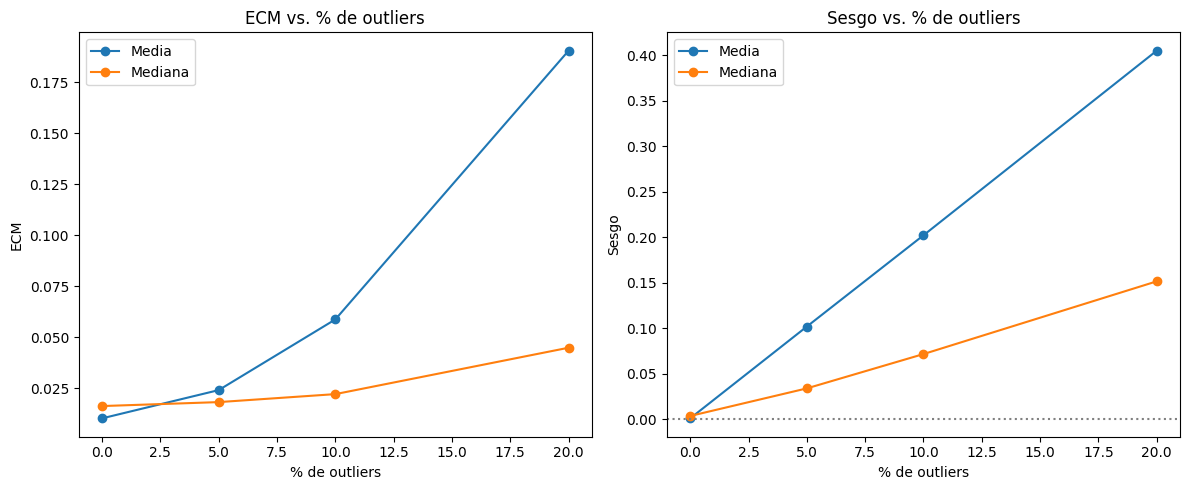

In [5]:
#Ahora realizamos el grafico:
x = [i*100 for i in porcentajes] #Genero un vector con los porcentajes
ecm_media    = [ECM(mu_0, resultados[i]['medias'])   for i in porcentajes] #Genero el ECM para la media y para cada uno de los niveles de contaminacion muestral.
ecm_mediana  = [ECM(mu_0, resultados[i]['medianas']) for i in porcentajes] #Hago lo mismo para la mediana.
sesgo_media_ = [sesgo(mu_0, resultados[i]['medias'])   for i in porcentajes] #Calculo el sesgo empirico de la media muestral.
sesgo_mediana_ = [sesgo(mu_0, resultados[i]['medianas']) for i in porcentajes]

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].plot(x, ecm_media, marker='o', label='Media')
ax[0].plot(x, ecm_mediana, marker='o', label='Mediana')
ax[0].set_xlabel('% de outliers')
ax[0].set_ylabel('ECM')
ax[0].set_title('ECM vs. % de outliers')
ax[0].legend()

#Ahora el segundo grafico:
ax[1].plot(x, sesgo_media_, marker='o', label='Media')
ax[1].plot(x, sesgo_mediana_, marker='o', label='Mediana')
ax[1].axhline(0, color='gray', linestyle=':')
ax[1].set_xlabel('% de outliers')
ax[1].set_ylabel('Sesgo')
ax[1].set_title('Sesgo vs. % de outliers')
ax[1].legend()

plt.tight_layout()
plt.show()

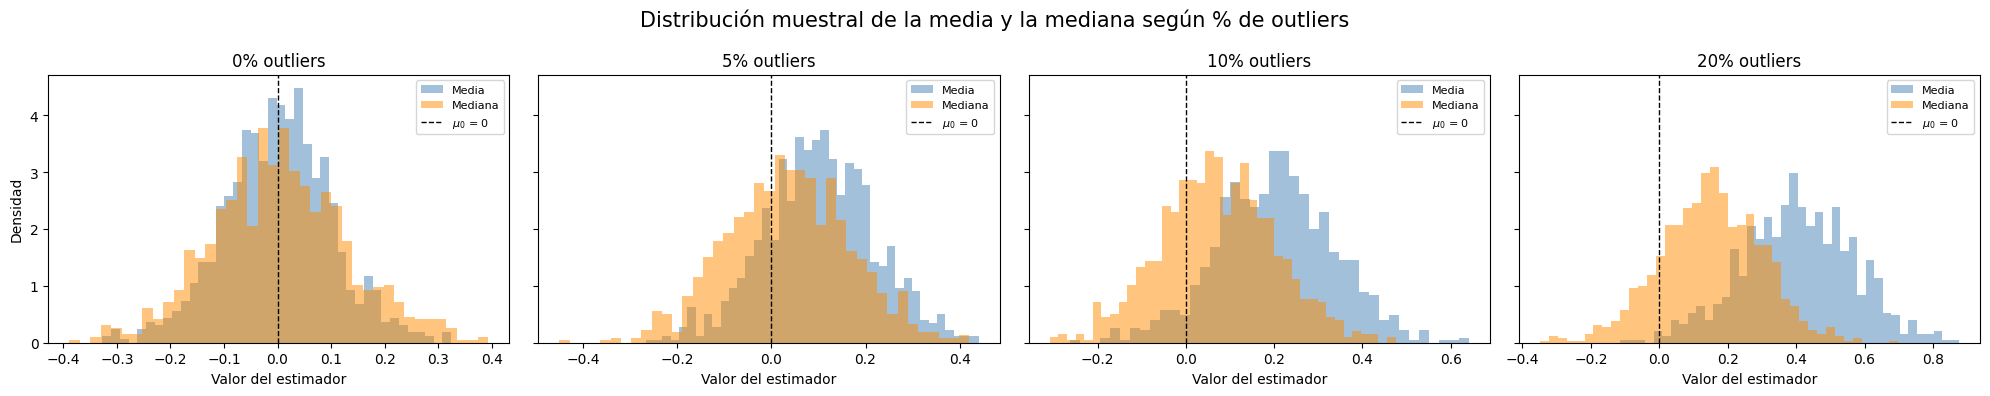

In [6]:
n_plots = len(porcentajes)
fig, axes = plt.subplots(1, n_plots, figsize=(5*n_plots, 4), sharey=True) #El ultimo argumento se usa para que todos los graficos comparatan el eje Y.
#Adicionalmente, para cada grafico se fija un ancho de 5 pulgadas (por eso se la multiplica por la cantidad de porcentajes).

for ax, i in zip(axes, porcentajes):
  #Obtengo las medias y las medianas simuladas para cada uno de los niveles de contaminacion muestral (1000 para cada uno).
    medias = resultados[i]['medias']
    medianas = resultados[i]['medianas']

    ax.hist(medias, bins=40, alpha=0.5, label='Media', color='steelblue', density=True)
    ax.hist(medianas, bins=40, alpha=0.5, label='Mediana', color='darkorange', density=True)
    ax.axvline(mu_0, color='black', linestyle='--', linewidth=1, label=fr'$\mu_0$ = {mu_0}') #Linea vertical para denotar a la verdadera media.
    ax.set_title(f'{i*100:.0f}% outliers')
    ax.set_xlabel('Valor del estimador')
    ax.legend(fontsize=8)

#Solo visualizo el eje Y para el primer grafico.
axes[0].set_ylabel('Densidad')
plt.suptitle('Distribución muestral de la media y la mediana según % de outliers', fontsize = 15)
plt.tight_layout()
plt.show()

En las visualizaciones construidas puede observarse lo que se comentaba con anterioridad. Si bien el ECM es mayor para la mediana cuando no existen outliers en la muestra (lo cual esta determinado en parte por el hecho de que este ultimo es un estimador sesgado de la mediana poblacional. Consecuentemente dado que los datos provienen de una distribucion simetrica, entonces la mediana tambien estimara insesgadamente a la media poblacional en este caso), el mismo crece ligeramente con el aumento de la contaminacion en la muestra. No sucede lo mismo con el estimador de la media, cuyo crecimiento se acelera con la mayor contaminacion muestral. Esto puede observarse particularmente en la primera de las visualizaciones.

En la segunda de las visualizaciones puede observarse como la distribucion de la media muestral se va corriendo hacia la derecha (dado que los outliers se encuentran en ese lado de la distribucion) a medida que el nivel de contaminacion aumenta. Si bien ocurre lo mismo con la distribucion de la mediana muestral, dicho proceso es mucho mas lento en este caso y la distribucion se torna notoriamente sesgada unicamente en el caso en que los outliers representan el 20% de la muestra.

En definitiva, y como se comentaba con anterioridad, la mediana es mas robusta ante la presencia de valores extremos para capturar la tendencia central de una distribucion que la media.

#Ejercicio 1.2

In [7]:
#Primeramente simulo un conjunto de parametros y una distribucion para los datos:
np.random.seed(1395)
n=100
#Modelo verdadero:
beta0_true = 2.0
beta1_true = 5.0
 #Simulo una distribucion uniforme para X y una normal para el error de estimacion:

x = np.random.uniform(0, 10, n)


In [8]:
#Construyo la matriz con las constantes
X = np.column_stack([np.ones(n),x])

In [9]:
#Ademas, calculo una funcion para calcular a 'mano' OLS:

from scipy.optimize import minimize

def ols(x,y):
  xTX = np.dot(X.T,X) #Multiplica las matrices. Alternativamente, puede realizarse con el comando @.
  xTX_inv = np.linalg.inv(xTX) #Esto invierte la matriz resultante.
  xTY = np.dot(X.T,y)
  beta_hat = np.dot(xTX_inv,xTY)
  return beta_hat

#Tambien defino la funcion para calcular el estimador LAD:
def lad(X, y, beta_init):
    #Definimos la función siguiente funcion que calcula la suma de los residuos.
    def suma_errores_absolutos(beta):
        prediccion = X @ beta
        residuos = y - prediccion
        return np.sum(np.abs(residuos))

    #Mediante la siguiente funcion minimizo la suma de los residuos, partiendo de un conjunto de valores iniciales (los estimados mediante OLS)
    resultado = minimize(suma_errores_absolutos, beta_init)

    # Retornamos los coeficientes

    return resultado.x

In [10]:
#Ahora si hago la simulacion:
np.random.seed(1395)
simulaciones = 500
resultados = {}
for i in porcentajes:
  N0 = int(n*(1-i))
  N1 = int(n*i)
  estimaciones_ols = np.empty(simulaciones)
  estimaciones_lad = np.empty(simulaciones)
  for j in range(simulaciones): #Para la simulacion utilizo los valores para la media y la varianza propuestos anteriormente
    error_true = np.random.normal(mu_0,sigma_0, N0)
    error_contaminado = np.random.normal(mu_1,sigma_1, N1)
    error_completo = np.concatenate((error_true,error_contaminado))
    y = beta0_true + beta1_true * x + error_completo
    beta_hat = ols(X,y)
    beta_hat_lad = lad(X, y, beta_hat)
    estimaciones_ols[j] = beta_hat[1]
    estimaciones_lad[j] = beta_hat_lad[1]
  resultados[i] = {'ols':estimaciones_ols , 'lad':estimaciones_lad}



In [11]:
#Ahora calculo tanto el sesgo como el error cuadratico medio para cada uno de los estimadores y porcentajes de contaminacion.
sesgo_ols = [sesgo(beta1_true, resultados[i]['ols']) for i in porcentajes]
sesgo_lad = [sesgo(beta1_true, resultados[i]['lad']) for i in porcentajes]
ecm_ols = [ECM(beta1_true, resultados[i]['ols']) for i in porcentajes]
ecm_lad = [ECM(beta1_true, resultados[i]['lad']) for i in porcentajes]


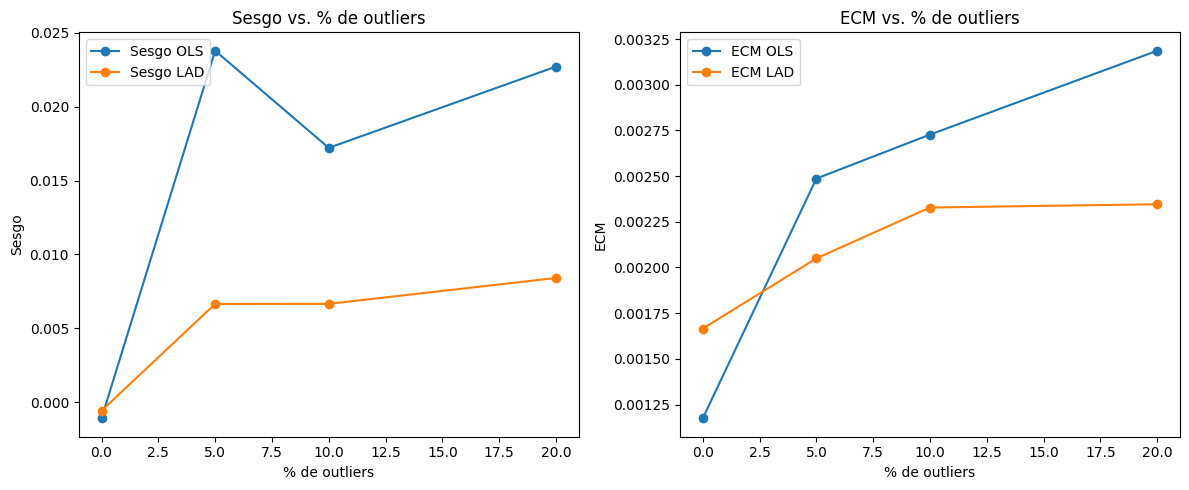

In [12]:
#Realizo un grafico de lineas similar al de la seccion anterior dado que me parece el mas explicativo.
fig, ax = plt.subplots(1,2,figsize=(12,5))
eje_x = [i*100 for i in porcentajes] #Genero un vector con los porcentajes
ax[0].plot(eje_x, sesgo_ols, marker='o', label='Sesgo OLS')
ax[0].plot(eje_x, sesgo_lad, marker='o', label='Sesgo LAD')
ax[0].set_xlabel('% de outliers')
ax[0].set_ylabel('Sesgo')
ax[0].set_title('Sesgo vs. % de outliers')
ax[0].legend(loc = 'upper left')

ax[1].plot(eje_x,ecm_ols, marker='o', label='ECM OLS')
ax[1].plot(eje_x,ecm_lad, marker='o', label='ECM LAD')
ax[1].set_xlabel('% de outliers')
ax[1].set_ylabel('ECM')
ax[1].set_title('ECM vs. % de outliers')
ax[1].legend()

plt.tight_layout()
plt.show()

Como puede observase en la visualizacion anterior, ante la inexistencia de outliers o contaminacion muestral el estimador de minimos cuadrados ordinarios tiene mejor desempeño para predecir el valor de $β_1$ que el estimador LAD. Sin embargo, a medida que la contaminacion muestral se incrementa OLS va perdiendo eficacia. De hecho , como puede verse en la visualizacion sobre las comparativas de los errores cuadraticos medios, el estimador LAD ya comienza a comportarse mejor incluso ante niveles de contaminacion del 5%.

En conclusion, en condiciones normales, el estimador OLS es mas eficiente que el estimador LAD. Si embargo, como consecuencia de la mayor ponderacion realizada por OLS a las observaciones con valores extremos, esa mayor eficiencia se diluye ante la presencia de outliers. Como se comento con anterioridad, no se necesita de gran nivel de contaminacion para que esto suceda. Con un 5% de contaminacion muestral el desempeño de OLS es peor que el de LAD y esa diferencia en el desempeño se acrecienta con el aumento en el nivel de contaminacion.

#Ejercicio 2

In [50]:
#Simulo las variables de acuerdo a lo que plantea el ejercicio.
x = np.random.normal(0,1, n)

z_continua = 1.5*x + np.random.normal(0,2,n)

w_continua = -2.1*x + np.random.normal(0,1,n)

In [51]:
#Ahora lo que hago es discretizar las variables generadas anteriormente.
z = pd.qcut(z_continua,q=4,labels=[1,2,3,4]).astype(int)
"""Basicamente lo que hace este comando es transformar el 25% de las observaciones mas bajas en 1, el siguiente 25% en 2 y asi sucesivamente."""
w = pd.qcut(w_continua,q=4,labels=[1,2,3,4]).astype(int)

error = np.random.normal(0,2,n)

#Genero la variable dependiente. No se agrega a x en el modelo verdadero.
y = 5 * z + 3 * w + error

In [55]:
#Importo el paquete que utilizare para calcular las regresiones.
import statsmodels.api as sm

x_const = sm.add_constant(x)

In [60]:
modelo = sm.OLS(y,x_const).fit()
print(modelo.summary())
#Notese que la variable X no es significativa al regresarla sobre la variable dependiente.

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                     1.498
Date:                Sun, 09 Aug 2026   Prob (F-statistic):              0.221
Time:                        14:51:21   Log-Likelihood:                -6209.0
No. Observations:                2000   AIC:                         1.242e+04
Df Residuals:                    1998   BIC:                         1.243e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         20.0225      0.121    165.873      0.0

In [57]:
matriz = np.column_stack((x,z))
matriz_const = sm.add_constant(matriz)

In [59]:
#Para el modelo condicional Y ~ X + Z el coeficiente que acompaña a X es negativo y estadisticamente significativo.
modelo_control = sm.OLS(y,matriz_const).fit()
print(modelo_control.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.755
Model:                            OLS   Adj. R-squared:                  0.755
Method:                 Least Squares   F-statistic:                     3085.
Date:                Sun, 09 Aug 2026   Prob (F-statistic):               0.00
Time:                        14:51:10   Log-Likelihood:                -4801.4
No. Observations:                2000   AIC:                             9609.
Df Residuals:                    1997   BIC:                             9626.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          7.6501      0.169     45.391      0.0

In [61]:
#Por ultimo veamos el caso de la regresion Y ~ X + W
matriz_w = np.column_stack((x,w))
matriz_w_const = sm.add_constant(matriz_w)
modelo_w = sm.OLS(y,matriz_w_const).fit()
print(modelo_w.summary())
# El coeficiente que acompaña a X es positivo y estadisticamente significativo.

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.089
Model:                            OLS   Adj. R-squared:                  0.088
Method:                 Least Squares   F-statistic:                     97.20
Date:                Sun, 09 Aug 2026   Prob (F-statistic):           5.21e-41
Time:                        14:51:58   Log-Likelihood:                -6116.9
No. Observations:                2000   AIC:                         1.224e+04
Df Residuals:                    1997   BIC:                         1.226e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         13.5844      0.478     28.429      0.0

In [20]:
#Para evitar la repeticion en el codigo, simulo todas las especificaciones de forma conjunta.
tamaños = [10, 20, 50, 100, 500]
especificaciones = ['sin_control', 'con_z', 'con_w']
estimaciones_tamanio = {n: {esp: [] for esp in especificaciones} for n in tamaños}

np.random.seed(1395)
for n in tamaños:
    for j in range(1000):
        x = np.random.normal(0, 1, n)
        z_continua = 1.5*x + np.random.normal(0, 2, n)
        w_continua = -2.1*x + np.random.normal(0, 1, n)
        z = pd.qcut(z_continua, q=4, labels=[1, 2, 3, 4]).astype(int)
        w = pd.qcut(w_continua, q=4, labels=[1, 2, 3, 4]).astype(int)
#El comando pd.qcut sirve para convertir variables continuas en discretas (como pide el enunciado).
#Lo que hace este codigo es convertir el 25% de los valores mas bajos en unos, el siguiente 25% en 2 y asi sucesivamente hasta llegar a 4.
        error = np.random.normal(0, 2, n)
        y = 5 * z + 3 * w + error

        modelos = {
            'sin_control': sm.add_constant(x),
            'con_z': sm.add_constant(np.column_stack([x, z])),
            'con_w': sm.add_constant(np.column_stack([x, w])),
        }

        for nombre, X_diseño in modelos.items():
            beta_x = sm.OLS(y, X_diseño).fit().params[1]
            estimaciones_tamanio[n][nombre].append(beta_x)

# Convertir listas a arrays de numpy al final
for n in tamaños:
    for esp in especificaciones:
        estimaciones_tamanio[n][esp] = np.array(estimaciones_tamanio[n][esp])

In [21]:
len(estimaciones_tamanio[500]['con_z'])

1000

In [22]:
#Calculo los sesgos para cada uno de los tamaños muestrales.
sesgos_modelo_sc = [sesgo(0,estimaciones_tamanio[i]['sin_control']) for i in tamaños]
print(sesgos_modelo_sc)
#En este caso particular de hecho el sesgo aumenta con el tamaño de la muestra.

[np.float64(-0.029287236366099305), np.float64(0.22663050442992097), np.float64(0.2532755617237991), np.float64(0.2765517351219601), np.float64(0.3036684847960341)]


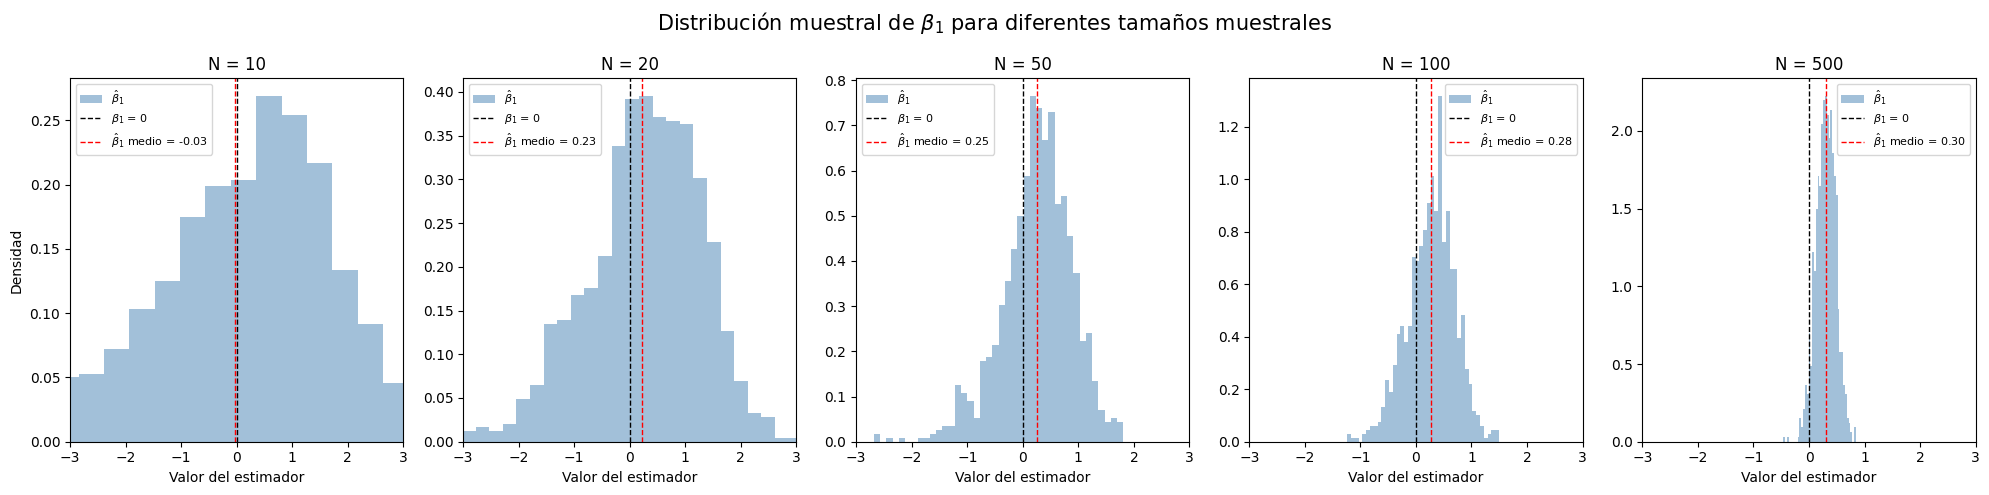

In [23]:
#Veamos la distribucion del estimador para el caso del modelo sin controles (donde el verdadero beta es igual a cero):
#A su vez, vemos como ajusta la distribucion normal a nuestros datos.
n_plots = len(tamaños)
fig, axes = plt.subplots(1, n_plots, figsize=(4*n_plots, 5), sharex = True)
#Adicionalmente, para cada grafico se fija un ancho de 5 pulgadas (por eso se la multiplica por la cantidad de porcentajes).

for ax, i in zip(axes, tamaños):
  #Obtengo las medias y las medianas simuladas para cada uno de los niveles de contaminacion muestral (1000 para cada uno).
    betas = estimaciones_tamanio[i]['sin_control']
    mu_emp, std_emp = betas.mean(), betas.std()

    ax.hist(betas, bins=40, alpha=0.5, label=r'$\hat\beta_1$', color='steelblue', density=True)
    ax.axvline(0, color='black', linestyle='--', linewidth=1, label=fr'$\beta_1$ = 0') #Linea vertical para denotar a la verdadera media.
    ax.axvline(mu_emp, color='red', linestyle='--', linewidth=1, label=fr'$\hat\beta_1$ medio = {mu_emp:.2f}')
    ax.set_xlim(-3,3)
    ax.set_title(f'N = {i}')
    ax.set_xlabel('Valor del estimador')
    ax.legend(fontsize=8)

#Solo visualizo el eje Y para el primer grafico.
axes[0].set_ylabel('Densidad')
plt.suptitle(r'Distribución muestral de $\beta_1$ para diferentes tamaños muestrales', fontsize = 15)
plt.tight_layout()
plt.show()

Notese que el sesgo, en lugar de disminuir con el aumento en el tamaño de la muestra, se acrecienta. Visualmente, la linea roja (que denota a la media empirica de las estimaciones de $\hat\beta_1$) se aleja cada vez mas del verdadero valor del parametro $β_1$.

Notese a si mismo que se forzo a que los graficos compartan el eje X de modo de no ser tan engañosos a primera vista. De todas formas, aun asi logra capturarse el proceso mencionado de aumento del sesgo con el incremento del tamaño muestral.

Este comportamiento corresponde al caso en el cual al modelo no se le adicionan controles.

In [24]:
#Ahora, al igual que antes, calculo el sesgo para los diferentes tamaños muestrales.

sesgos_modelo_c1 = [sesgo(0,estimaciones_tamanio[i]['con_z']) for i in tamaños]
print(sesgos_modelo_c1)

[np.float64(-3.278799593134871), np.float64(-2.911673410904161), np.float64(-2.8737567306586227), np.float64(-2.7954846037344403), np.float64(-2.767375216642796)]


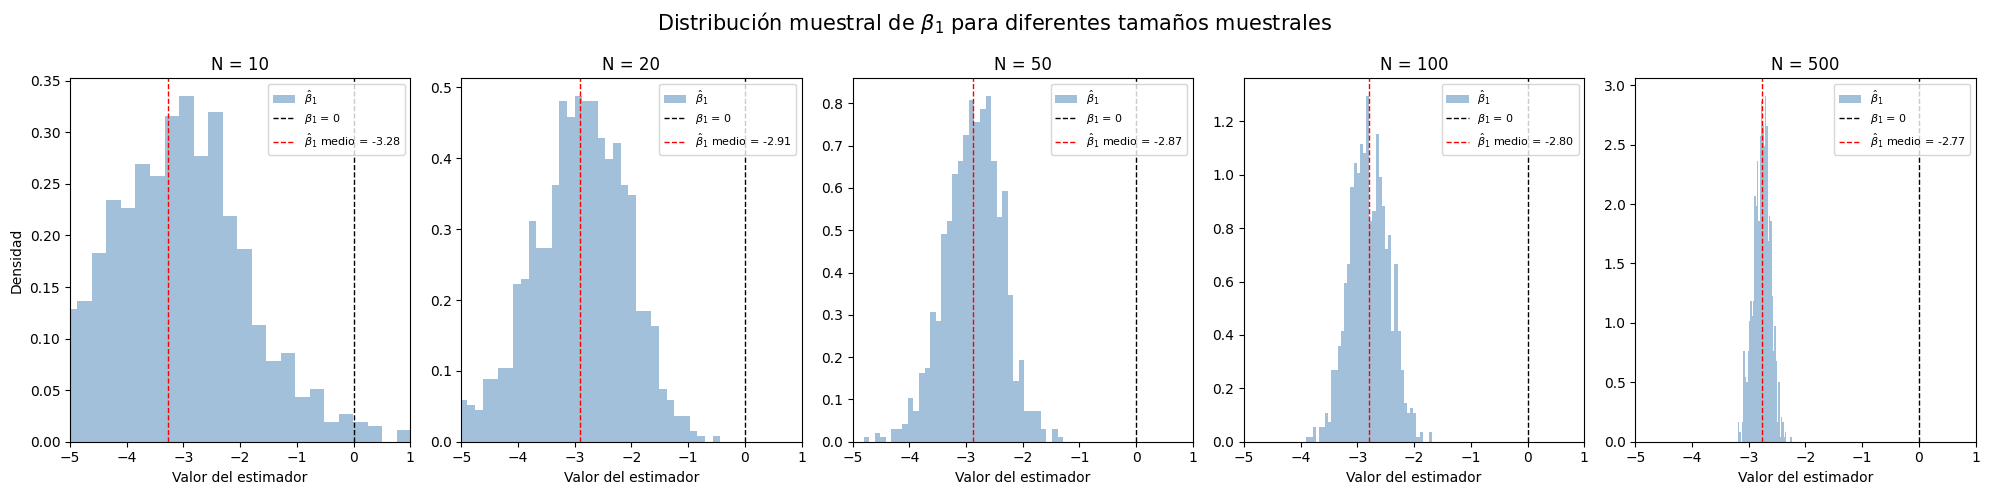

In [25]:
#Ahora vamos a realizar el mismo grafico que antes:
n_plots = len(tamaños)
fig, axes = plt.subplots(1, n_plots, figsize=(4*n_plots, 5), sharex = True)


for ax, i in zip(axes, tamaños):
  betas = estimaciones_tamanio[i]['con_z']
  mu_emp, std_emp = betas.mean(), betas.std()
  ax.hist(betas, bins=40, alpha=0.5, label=r'$\hat\beta_1$', color='steelblue', density=True)
  ax.axvline(0, color='black', linestyle='--', linewidth=1, label=fr'$\beta_1$ = 0') #Linea vertical para denotar a la verdadera
  ax.axvline(mu_emp, color='red', linestyle='--', linewidth=1, label=fr'$\hat\beta_1$ medio = {mu_emp:.2f}')
  ax.set_xlim(-5,1)
  ax.set_title(f'N = {i}')
  ax.set_xlabel('Valor del estimador')
  ax.legend(fontsize=8)

axes[0].set_ylabel('Densidad')
plt.suptitle(r'Distribución muestral de $\beta_1$ para diferentes tamaños muestrales', fontsize = 15)
plt.tight_layout()
plt.show()

In [26]:
sesgos_modelo_c2 = [sesgo(0,estimaciones_tamanio[i]['con_w']) for i in tamaños]
print(sesgos_modelo_c2)

[np.float64(3.0285946856136734), np.float64(3.0853977146601643), np.float64(3.0741785613474315), np.float64(2.950881860470712), np.float64(2.9057842820568065)]


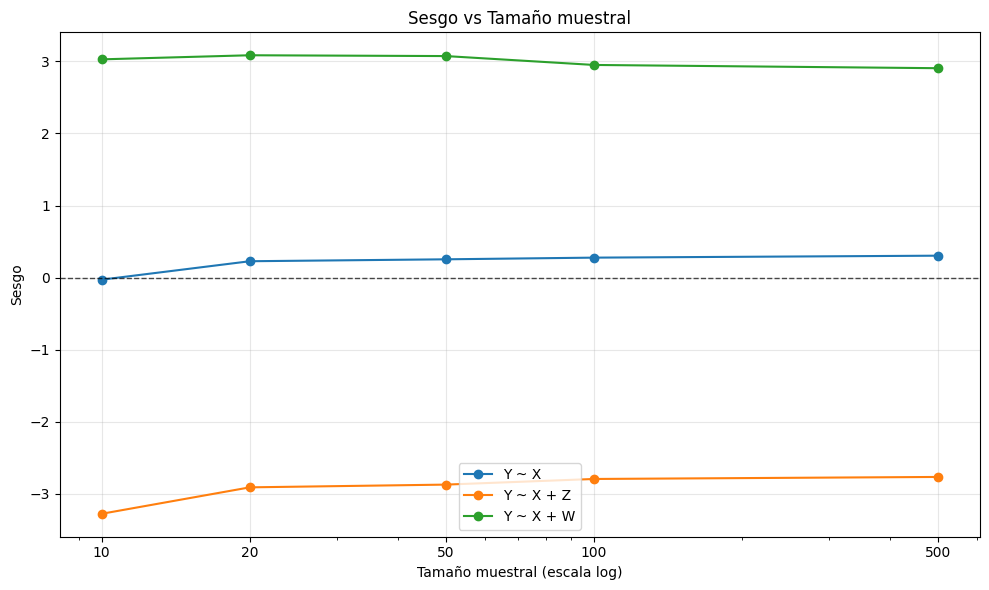

In [27]:
#Hago un grafico para denotar la evolucion del sesgo con las diferentes especificaciones:
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
eje_x = tamaños #El eje X va a tomar como valor a los diferentes tamaños muestrales.

ax.plot(eje_x, sesgos_modelo_sc, marker='o', label='Y ~ X')
ax.plot(eje_x, sesgos_modelo_c1, marker='o', label='Y ~ X + Z')
ax.plot(eje_x, sesgos_modelo_c2, marker='o', label='Y ~ X + W')

ax.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.7)
ax.set_xscale('log') #Para suavizar el eje X.
ax.set_xticks(tamaños)
ax.set_xticklabels(tamaños)  # para que muestre los valores reales, no potencias de 10

ax.set_xlabel('Tamaño muestral (escala log)')
ax.set_ylabel('Sesgo')
ax.set_title('Sesgo vs Tamaño muestral')
ax.grid(alpha=0.3)
ax.legend(loc='best')
plt.tight_layout()
plt.show()


Como puede observarse, y como se menciono con anterioridad, si bien para el modelo sin controles el sesgo aumenta con el tamaño de la muestra, no ocurre lo mismo con los demas modelos. Si bien ligeramente, el sesgo se 'acerca' (muy lento) a cero. Esto quiere decir que el sesgo por variables omitidas no desaparece al agregar controles.

#Ejercicio 2.2

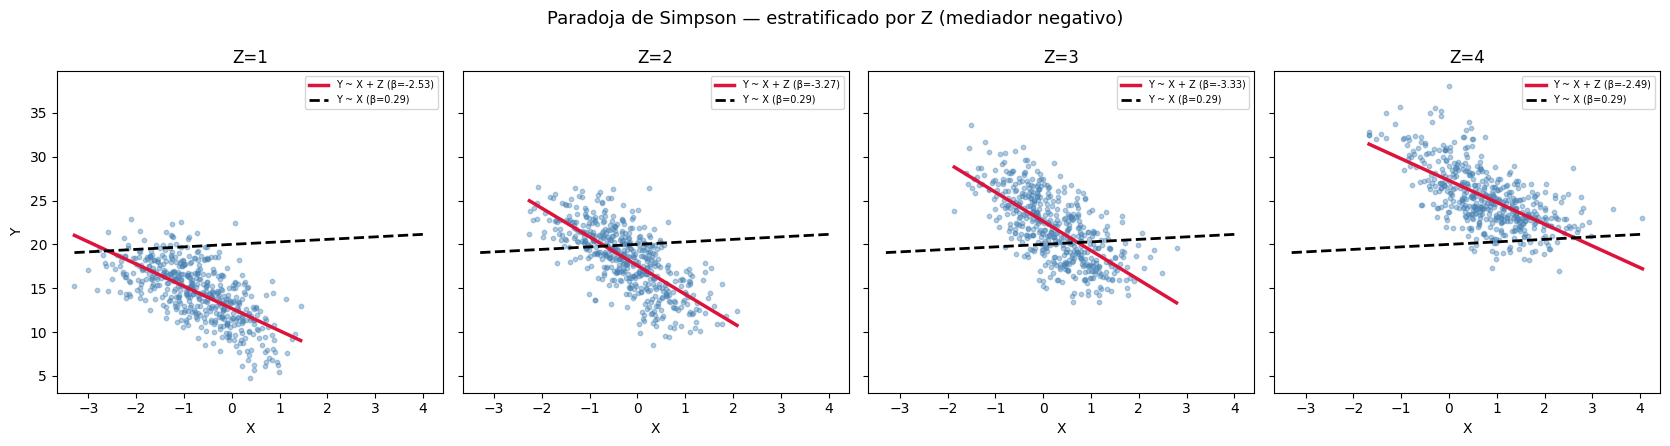

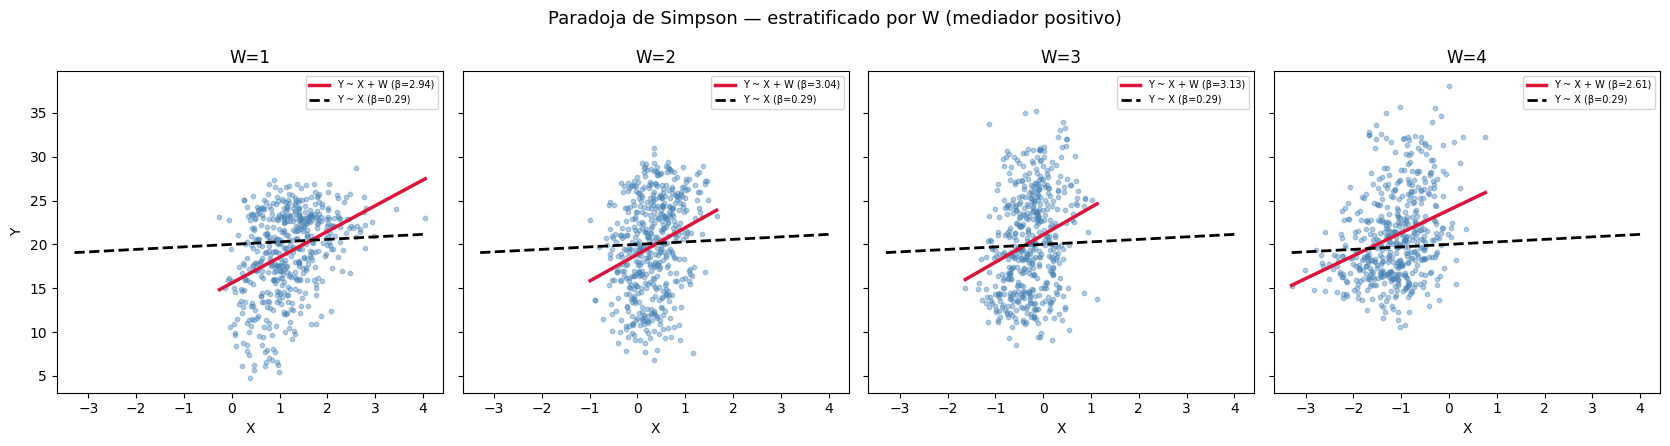

In [28]:
#Para poder realizar el grafico simulo una unica muestra en lugar de hacer uso de las diferentes muestras creadas anteriormente.

np.random.seed(3261395)
n = 2000 #Genero una muestra de tamaño 2000

x = np.random.normal(0, 1, n)
z_continua = 1.5*x + np.random.normal(0, 2, n)
w_continua = -2.1*x + np.random.normal(0, 1, n)

#Ahora vuelvo las variables z_continua y w_continua en discretas
z = pd.qcut(z_continua, q=4, labels=[1, 2, 3, 4]).astype(int)
w = pd.qcut(w_continua, q=4, labels=[1,2,3,4]).astype(int)

#Genero los errores y la variable dependiente.
error = np.random.normal(0, 2, n)
y = 5 * z + 3 * w + error


#Genero una funcion para realizar los graficos y evitar repeticion en el codigo:
def graficar_small_multiples(df, columna_grupo, beta_marginal, xs_full, ys_full, titulo):
    niveles = sorted(df[columna_grupo].unique())
    fig, axes = plt.subplots(1, len(niveles), figsize=(4.2*len(niveles), 4.5), sharey=True)
    #Notese que seteo que los graficos compartan el eje Y. Asimismo, la longitud es igual a la cantidad de valores que toma la variable (4 en este caso).
    for ax, nivel in zip(axes, niveles):
        sub = df[df[columna_grupo] == nivel] #Hago un grafico para cada valor que toma la variable. 'Recorto' el dataframe para esos valores unicamente.
        ax.scatter(sub['x'], sub['y'], s=10, alpha=0.4, color='steelblue')

        X_sub = sm.add_constant(sub['x']) #Agrego constante.
        modelo_sub = sm.OLS(sub['y'], X_sub).fit()
        xs = np.linspace(sub['x'].min(), sub['x'].max(), 50)
        ys = modelo_sub.params.iloc[0] + modelo_sub.params.iloc[1] * xs
        beta_grupo = modelo_sub.params.iloc[1]

        ax.plot(xs, ys, color='crimson', linewidth=2.5, label=f'Y ~ X + {(columna_grupo).upper()} (β={beta_grupo:.2f})')
        ax.plot(xs_full, ys_full, color='black', linewidth=2, linestyle='--',
                label=f'Y ~ X (β={beta_marginal:.2f})')

        ax.set_title(f'{columna_grupo.upper()}={nivel}')
        ax.set_xlabel('X')
        ax.legend(fontsize=7, loc='upper right')

    axes[0].set_ylabel('Y')
    plt.suptitle(titulo, fontsize=13)
    plt.tight_layout()
    return fig

# Notese que las regresiones las corro para solo una muestra de datos (con n=2000).
df = pd.DataFrame({'x': x, 'y': y, 'z': z, 'w': w}) #Creo un dataframe
X_full = sm.add_constant(df['x'])
modelo_marginal = sm.OLS(df['y'], X_full).fit()
xs_full = np.linspace(df['x'].min(), df['x'].max(), 50)
ys_full = modelo_marginal.params.iloc[0] + modelo_marginal.params.iloc[1] * xs_full
beta_marginal = modelo_marginal.params.iloc[1]

# Uso:
graficar_small_multiples(df, 'z', beta_marginal, xs_full, ys_full, 'Paradoja de Simpson — estratificado por Z (mediador negativo)')
plt.show()

graficar_small_multiples(df, 'w', beta_marginal, xs_full, ys_full, 'Paradoja de Simpson — estratificado por W (mediador positivo)')
plt.show()

Por el teorema de Frisch-Waugh-Lovell se sabe que, en una regresion multiple,  el efecto de X sobre Y representa el efecto que dicha variable provoca sobre la variable dependiente luego de extraer la correlacion entre X y las demas variables explicativas.
Los resultados demuestran que X no tiene efecto directo sobre Y (de hecho, anteriormente se demostro que el coeficiente no es estadisticamente diferente a cero. En este caso 0.29). La relación de X con Y opera exclusivamente a través de dos canales mediadores :𝑋→𝑍→𝑌 (de signo positivo) y 𝑋→W→𝑌 (de signo negativo).
Al incorporar Z como control, el modelo 𝑌∼𝑋+𝑍 compara observaciones con igual nivel de Z, neutralizando estadísticamente el canal X→Z→Y. El coeficiente resultante para X refleja entonces únicamente el canal remanente X→W→Y (por eso la pendiente negativa para el coeficiente que accompaña a X cuando se regresa Y ~ X + Z). De forma equivalente, el coeficiente resultante para el modelo Y~ X+W neutraliza el canal X→W→Y y deja activo el otro X→Z→Y. Esto explica el coeficiente positivo para $β_1$ en este caso.
Este patron (en el que el signo y la magnitud del coeficiente de interés se invierten según qué variable se incluye como control) constituye una manifestación de la paradoja de Simpson, ilustrada gráficamente al estratificar la muestra por niveles de Z y de W.


#Ejercicio 3

In [29]:

#Importo el dataframe gapminder:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
url = 'https://raw.githubusercontent.com/lucianobunino/Trabajo_Pr-ctico_R/refs/heads/main/gapminder.csv'
gap = pd.read_csv(url)


In [30]:
#Quiero ver el rango temporal del dataframe:
print('El rango temporal es :', gap['year'].min(), '-', gap['year'].max())

El rango temporal es : 1960 - 2010


Notese que el dataframe solo contiene datos pertenecientes al periodo 1960-2010, por lo que no se dispondra de los datos correspondientes al rango temporal 1952-1959 (los cuales eran requeridos en la consigna).

In [31]:
#El pais seleccionado, por obvias razones, sera Argentina.
#Por esta razon selecciono unicamente los datos correspondientes a dicho pais
datos_arg = gap[gap['country']=='Argentina'].query('year >= 1952 & year <= 2007')

In [32]:
#Me fijo el nombre de las columnas:
gap.columns


Index(['country', 'world_region', 'year', 'children_per_woman',
       'life_expectancy', 'income_per_person', 'is_oecd', 'income_groups',
       'population', 'main_religion', 'child_mortality',
       'life_expectancy_female', 'life_expectancy_male'],
      dtype='object')

In [33]:
#En primer lugar, para el dataframe completo calculo la media de la esperanza de vida:
#Filtro primero los años de interes:
datos_totales = gap.query('year >= 1952 & year <= 2007')
medias_ev = datos_totales.groupby('year')['life_expectancy'].mean() #Media de la esperanza de vida mundial.

In [34]:
#Ahora calculo la diferencia entre el promedio mundial de esperanza de vida y la esperanza de vida de Argentina:
datos_arg['Dif_mundo'] = datos_arg['life_expectancy'] - datos_arg['year'].map(medias_ev)

Ademas de la comparativa con respecto al promedio mundial me interesa observar la differencia respecto a los paises latinoamericanos y la diferencia respecto a los paises miembros de la OCDE.

In [35]:
latam_paises = ['Argentina', 'Brazil', 'Chile', 'Colombia', 'Mexico', 'Peru', 'Uruguay', 'Bolivia', 'Paraguay', 'Ecuador']
paises_OCDE = ["Australia","Austria","Belgium","Canada","Chile","Colombia","Costa Rica","Czechia", "Denmark","Estonia","Finland","France","Germany","Greece","Hungary","Iceland","Ireland","Israel","Italy","Japan","Korea","Latvia","Lithuania","Luxembourg","Mexico","Netherlands","New Zealand","Norway","Poland","Portugal", "Slovak Republic","Slovenia","Spain","Sweden","Switzerland","Türkiye","United Kingdom","United States"]
#Luego de poner los paises uno por uno me di cuenta que habia una columna que los identificaba...

In [36]:
#Calculo el promedio de la esperanza de vida para cada año para estos paises:
datos_latam = gap[gap['country'].isin(latam_paises)].query('year > = 1952 & year <= 2007')
datos_ocde = gap[gap['country'].isin(paises_OCDE)].query('year > = 1952 & year <= 2007')

In [37]:
#Ahora calculo las diferencias respecto a los datos de argentina:
promedio_latam_por_año = datos_latam.groupby('year')['life_expectancy'].mean()
promedio_ocde_por_año = datos_ocde.groupby('year')['life_expectancy'].mean()

datos_arg['Dif_latam'] = datos_arg['life_expectancy'] - datos_arg['year'].map(promedio_latam_por_año)
datos_arg['Dif_ocde'] = datos_arg['life_expectancy'] - datos_arg['year'].map(promedio_ocde_por_año)

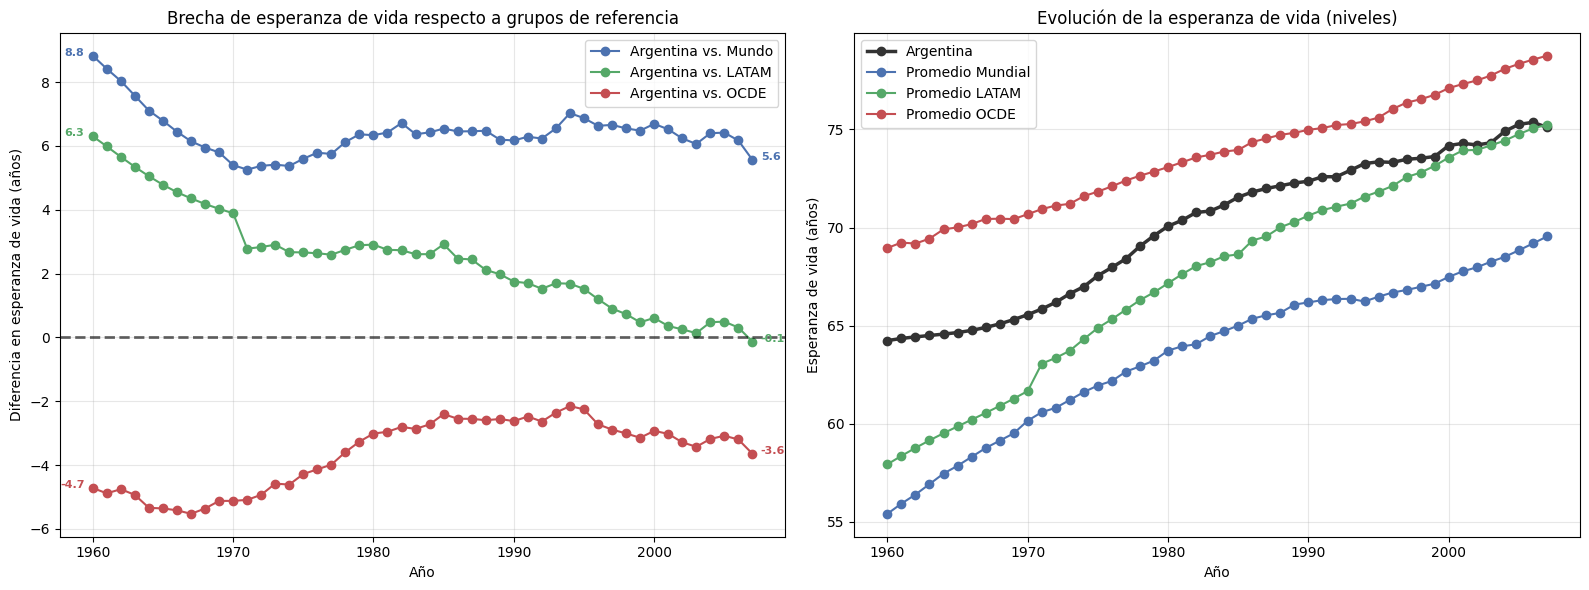

In [38]:
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# En el primer grafico la brecha:
ax[0].plot(datos_arg['year'], datos_arg['Dif_mundo'], marker='o', label='Argentina vs. Mundo', color='#4C72B0')
ax[0].plot(datos_arg['year'], datos_arg['Dif_latam'], marker='o', label='Argentina vs. LATAM', color='#55A868')
ax[0].plot(datos_arg['year'], datos_arg['Dif_ocde'], marker='o', label='Argentina vs. OCDE', color='#C44E52')

ax[0].axhline(0, color='black', linestyle='--', linewidth=2, alpha=0.6)
ax[0].set_xlabel('Año')
ax[0].set_ylabel('Diferencia en esperanza de vida (años)')
ax[0].set_title('Brecha de esperanza de vida respecto a grupos de referencia')
ax[0].legend(loc='best')
ax[0].grid(alpha=0.3)

for serie, color in [(datos_arg['Dif_mundo'], '#4C72B0'), (datos_arg['Dif_latam'], '#55A868'), (datos_arg['Dif_ocde'], '#C44E52')]:
    primer_año = datos_arg['year'].iloc[0]
    primer_valor = serie.iloc[0]
    ultimo_año = datos_arg['year'].iloc[-1]
    ultimo_valor = serie.iloc[-1]
    ax[0].annotate(f'{primer_valor:.1f}', (primer_año, primer_valor), #Anoto el ultimo y primer valor.
                    fontsize=8, xytext=(-6, 0), textcoords='offset points', color=color,
                    fontweight='bold', ha='right')
    ax[0].annotate(f'{ultimo_valor:.1f}', (ultimo_año, ultimo_valor),
                    fontsize=8, xytext=(6, 0), textcoords='offset points', color=color, fontweight='bold')

# Ahora el grafico en niveles.
ax[1].plot(datos_arg['year'], datos_arg['life_expectancy'], marker='o', label='Argentina', color='#333333', linewidth=2.5)
ax[1].plot(medias_ev.index, medias_ev.values, marker='o', label='Promedio Mundial', color='#4C72B0')
ax[1].plot(promedio_latam_por_año.index, promedio_latam_por_año.values, marker='o', label='Promedio LATAM', color='#55A868')
ax[1].plot(promedio_ocde_por_año.index, promedio_ocde_por_año.values, marker='o', label='Promedio OCDE', color='#C44E52')

ax[1].set_xlabel('Año')
ax[1].set_ylabel('Esperanza de vida (años)')
ax[1].set_title('Evolución de la esperanza de vida (niveles)')
ax[1].legend(loc='best')
ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

Como puede obsevarse en la anterior visualizacion, tanto la brecha con respecto al resto del mundo como con respecto a los paises de latinoamerica se ha reducido. Al principio de la serie Argentina poseia casi 9 años mas de esperanza de vida que el promedio mundial y mas de 6 años que el promedio de los paises latinoamericanos. Esto es, el desempeño Argentino, en lo que a expectativa de vida refiere, empeoro en terminos relativos con respecto a los grupos mencionados.
En cambio, si bien la brecha con OCDE tambien se redujo en el periodo considerado, dicha reduccion represento un mejoramiento para Argentina dado que se fue acercando a la mayor expectativa de vida que poseian los paises de la OCDE.  

Por ultimo, puede notarse en los ultimos años analizados un empeoramiento de la brecha de la esperanza de vida Argentina con respecto a la de los demas grupos de referencia, acercandose a los paises que estaban peor (mundo y latinoamerica) y alejandose de los que estaban mejor (OCDE).


In [39]:
datos_america = gap[gap['world_region'] == 'america']

In [40]:
#America esta compuesto por 35 paises
datos_america['country'].nunique()

35

In [41]:
datos_america.columns

Index(['country', 'world_region', 'year', 'children_per_woman',
       'life_expectancy', 'income_per_person', 'is_oecd', 'income_groups',
       'population', 'main_religion', 'child_mortality',
       'life_expectancy_female', 'life_expectancy_male'],
      dtype='object')

In [42]:
datos_america

,country,world_region,year,children_per_woman,life_expectancy,income_per_person,is_oecd,income_groups,population,main_religion,child_mortality,life_expectancy_female,life_expectancy_male
255,Argentina,america,1960,3.11,64.24,9765,False,upper_middle_income,20481781.0,christian,73.28,68.154,62.417
256,Argentina,america,1961,3.10,64.35,10299,False,upper_middle_income,20817270.0,christian,68.97,68.362,62.460
257,Argentina,america,1962,3.09,64.43,9976,False,upper_middle_income,21153042.0,christian,64.91,68.536,62.478
258,Argentina,america,1963,3.08,64.50,9589,False,upper_middle_income,21488916.0,christian,61.09,68.685,62.487
259,Argentina,america,1964,3.07,64.57,10418,False,upper_middle_income,21824427.0,christian,57.50,68.82,62.503
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9481,Venezuela,america,2006,2.60,75.17,16383,False,upper_middle_income,26850190.0,christian,17.90,76.95,69.186
9482,Venezuela,america,2007,2.56,75.00,17558,False,upper_middle_income,27247601.0,christian,17.44,77.016,69.260
9483,Venezuela,america,2008,2.53,74.73,18225,False,upper_middle_income,27635827.0,christian,17.14,77.066,69.326
9484,Venezuela,america,2009,2.50,74.82,17392,False,upper_middle_income,28031010.0,christian,17.01,77.099,69.379


In [43]:
datos_argentina = gap[gap['country']=='Argentina']

In [44]:
#Calculo la media del ingreso per capita, asi como tambien los percentiles de la distribucion (percentiles 0.25 y 0.75)
percentiles = datos_america.groupby('year')['income_per_person'].quantile([0.25, 0.5, 0.75]).unstack().rename(columns={0.25: 'p25', 0.5: 'p50', 0.75: 'p75'})
#El comando unstack() pasa los percentiles de indices a columnas
#Agrego la media al dataframe:
percentiles['media'] = datos_america.groupby('year')['income_per_person'].mean()
print(percentiles)

         p25      p50      p75         media
year                                        
1960  2979.5   4219.0   5768.5   5510.828571
1961  2934.0   4216.0   5899.0   5635.771429
1962  3095.0   4320.0   6024.5   5820.857143
1963  2909.5   4309.0   6299.0   5938.400000
1964  2994.0   4598.0   6458.5   6184.828571
1965  3077.0   4700.0   6477.0   6380.971429
1966  3198.0   4764.0   6823.5   6588.800000
1967  3299.5   4936.0   6931.5   6733.685714
1968  3349.5   5090.0   7122.0   6935.771429
1969  3495.5   5338.0   7377.0   7182.085714
1970  3609.5   5512.0   7642.5   7314.485714
1971  3736.5   5885.0   7776.5   7508.485714
1972  3807.0   6001.0   7875.0   7683.628571
1973  3974.5   6169.0   8356.5   7992.800000
1974  4157.5   6346.0   8290.0   8013.914286
1975  4358.0   6109.0   8863.0   7966.914286
1976  4787.0   6077.0   9500.0   8239.457143
1977  5161.0   6516.0   9816.5   8538.914286
1978  5317.0   6657.0  10215.0   8873.314286
1979  4897.5   6666.0  10628.0   9177.485714
1980  4859

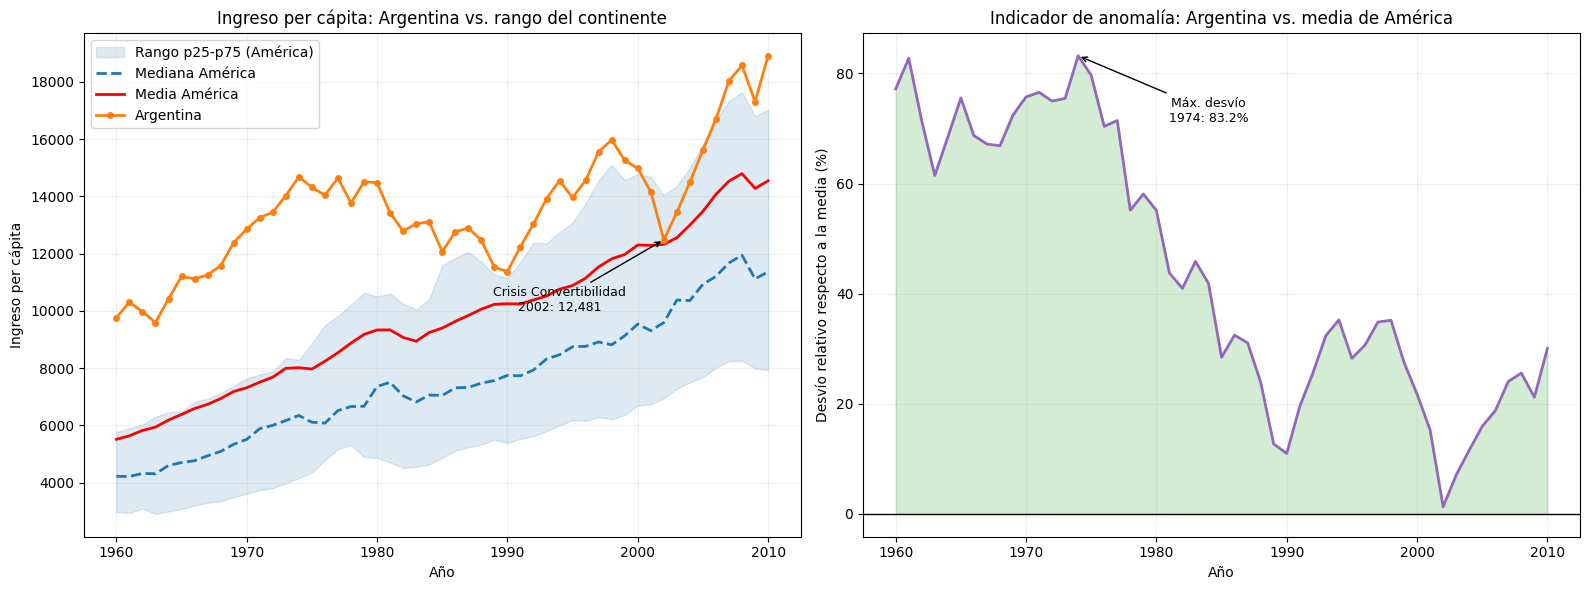

In [45]:
import matplotlib.pyplot as plt
#Lo que hago en primer lugar es definir un nuevo dataframe combinando los datos de Argentina con los del resto de America.
comparacion = datos_argentina.merge(
    percentiles, left_on='year', right_index=True
)
#Notese que relizo el join para poder obtener un unico dataframe con todos los datos necesarios.
comparacion['desvio_rel'] = (
    (comparacion['income_per_person'] - comparacion['media']) / comparacion['media']
) * 100  # en %
#Aqui calculo una medida de desviacion del PBIpc de Argentina respecto al PBIpc de america.

fig, ax = plt.subplots(1, 2, figsize=(16, 6), sharex=True) #Notese que hago compartir el eje X a ambos graficos.

#Relleno el espacio entre el percentil 25 y el percentil 75.
ax[0].fill_between(
    percentiles.index, percentiles['p25'], percentiles['p75'],
    alpha=0.15, color='tab:blue', label='Rango p25-p75 (América)'
)

#Mediana America:
ax[0].plot(
    percentiles.index, percentiles['p50'],
    linestyle='--', color='tab:blue', linewidth=2, label='Mediana América'
)
#Media America:
ax[0].plot(
    percentiles.index, percentiles['media'],
    linestyle='-', color='red', linewidth=2, label='Media América'
)
#Grafico para argentina
ax[0].plot(
    datos_argentina['year'],datos_argentina['income_per_person'],
    color='tab:orange', linewidth=2, marker='o', markersize=4, label='Argentina'
)
#Identifico el minimo de la serie (aquel punto en el cual Argentina se encontro mas cerca de la media del continente)
crisis = datos_argentina[
    (datos_argentina['year'] >= 2001) & (datos_argentina['year'] <= 2003)
]
fila_min = crisis.loc[crisis['income_per_person'].idxmin()]

ax[0].set_xlabel('Año')
ax[0].set_ylabel('Ingreso per cápita')
ax[0].set_title('Ingreso per cápita: Argentina vs. rango del continente')
ax[0].annotate(
    f"Crisis Convertibilidad\n{int(fila_min['year'])}: {fila_min['income_per_person']:,.0f}",
    xy=(fila_min['year'], fila_min['income_per_person']),
    xytext=(fila_min['year'] - 8, fila_min['income_per_person'] - 2500),
    arrowprops=dict(arrowstyle='->', color='black', lw=1),
    fontsize=9,
    ha='center'
)

ax[0].legend()
ax[0].grid(alpha=0.2)

#Ahora el segundo grafico, que muestra las desviaciones;
ax[1].axhline(0, color='black', linewidth=1, linestyle='-')
ax[1].plot(
    comparacion['year'], comparacion['desvio_rel'],
    color='tab:purple', linewidth=2
)
# Encuentro el punto de máxima desviación relativa
fila_max_desvio = comparacion.loc[comparacion['desvio_rel'].idxmax()]

# Relleno positivo (Argentina por encima) vs negativo (por debajo)
ax[1].fill_between(
    comparacion['year'], comparacion['desvio_rel'], 0,
    where=(comparacion['desvio_rel'] >= 0),
    color='tab:green', alpha=0.2, interpolate=True
)
ax[1].fill_between(
    comparacion['year'], comparacion['desvio_rel'], 0,
    where=(comparacion['desvio_rel'] < 0),
    color='tab:red', alpha=0.2, interpolate=True
)

ax[1].set_xlabel('Año')
ax[1].annotate(
    f"Máx. desvío\n{int(fila_max_desvio['year'])}: {fila_max_desvio['desvio_rel']:.1f}%",
    xy=(fila_max_desvio['year'], fila_max_desvio['desvio_rel']),
    xytext=(fila_max_desvio['year'] +10, fila_max_desvio['desvio_rel'] - 12),
    arrowprops=dict(arrowstyle='->', color='black', lw=1),
    fontsize=9,
    ha='center'
)
ax[1].set_ylabel('Desvío relativo respecto a la media (%)')
ax[1].set_title('Indicador de anomalía: Argentina vs. media de América')
ax[1].grid(alpha=0.2)




plt.tight_layout()
plt.show()

Como puede observarse en el grafico derecho, el indicador de desvio relativo de Argentina respecto al resto de los paises latinoamericanos alcanza su maximo en 1974, momento en el pais bajo analisis comienza un proceso de declinamiento sostenido. Hasta ese momento, Argentina se encontraba muy por encima del resto de los paises americanos, particularmente de los latinoamericanos.
Podria decirse que a partir de 1975, con el rodrigazo y el advenimiento de la dictadura un año despues, comienza un proceso de declive en Argentina. Ese declive, o bajo crecimiento relativo que experimento Argentina fue contemporaneo al alto crecimiento de paises como Chile y Brasil, lo cual provoco que la diferencia con el resto de los paises vaya disminuyendo.

El grafico de la izquierda es util para observar que el PBI per capita de Argentina se encontro durante casi toda la serie por encima tanto de la media, de la mediana y del percentil 75 de a distribucion del PBI per capita del resto de los paises Americanos. Por supuesto que, por la presencia de algunos Outliers (los paises mas ricos del continente: EEUU y Canada) la media se encuentra por encima de la mediana (que se demostro en el primer ejercicio es un estimador mas robusto de la tendencia central de la distribucion ante presencia de valores extremos). La unica excepcion al proceso mencionado se dio en los años cercanos al 2002, en el cual se entro en una de las peores crisis de la historia del pais y se salio de la convertibilidad. Este punto tambien es observable en el grafico de la derecha ,en el cual el mencionado año el grafico toca minimos.